In [3]:
!pip install wordcloud

In [5]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Wordcloud
from wordcloud import WordCloud

In [7]:
#Load Dataset
df = pd.read_csv("amazonreviews.tsv", sep="\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [9]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


(10000, 2)

In [11]:
#Data Cleaning
df.isnull().sum()

label     0
review    0
dtype: int64

In [17]:
df.dropna(inplace=True)

In [15]:
df.drop_duplicates(inplace=True)

In [19]:
# Text Preprocessing
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cheli\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [25]:
#Cleaning Function
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [27]:
df['clean_review'] = df['review'].apply(clean_text)

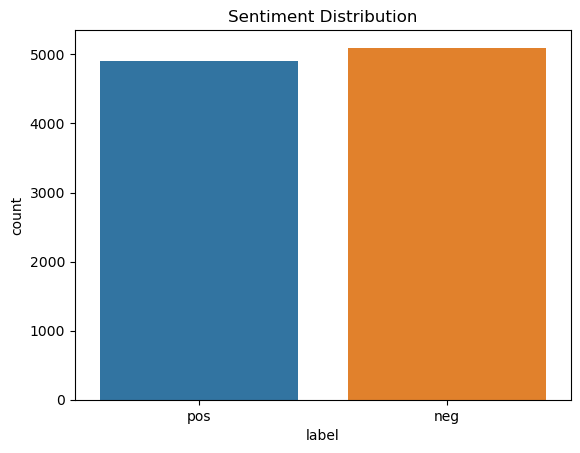

In [29]:
#Exploratory Data Analysis
#Sentiment Distribution
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")
plt.show()

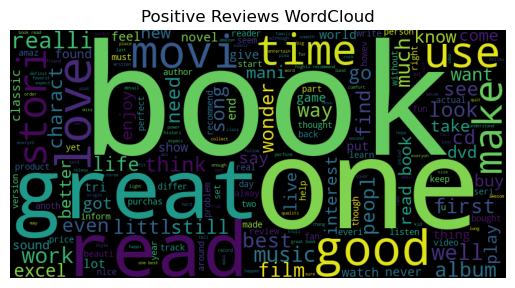

In [31]:
#Word Cloud (Positive Reviews)
pos_text = " ".join(df[df['label']=="pos"]['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(pos_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

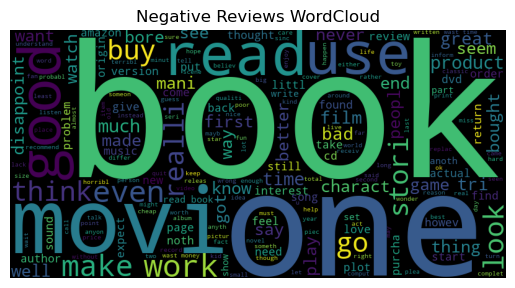

In [33]:
#Word Cloud (Negative Reviews)
neg_text = " ".join(df[df['label']=="neg"]['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(neg_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

In [35]:
#Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])

y = df['label']

In [37]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
#Model Training
#Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

pred_lr = lr_model.predict(X_test)

In [41]:
#Support Vector Machine (SVM)
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

pred_svm = svm_model.predict(X_test)

In [43]:
#Model Evaluation
#Logistic Regression
print("Accuracy:", accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

print(confusion_matrix(y_test, pred_lr))

Accuracy: 0.853
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1037
         pos       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

[[890 147]
 [147 816]]


In [45]:
#SVM
print("Accuracy:", accuracy_score(y_test, pred_svm))

print(classification_report(y_test, pred_svm))

print(confusion_matrix(y_test, pred_svm))


Accuracy: 0.8375
              precision    recall  f1-score   support

         neg       0.85      0.84      0.84      1037
         pos       0.83      0.84      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

[[870 167]
 [158 805]]


In [47]:
#Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X, y, cv=5)

print("Cross Validation Accuracy:", scores.mean())


Cross Validation Accuracy: 0.835


In [49]:
#Test Custom Review
review = ["This product is amazing and works perfectly"]

clean = clean_text(review[0])

vector = vectorizer.transform([clean])

prediction = lr_model.predict(vector)

print("Sentiment:", prediction[0])

Sentiment: pos
